In [24]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report,precision_score,recall_score,f1_score
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier

In [25]:
mydataset = pd.read_csv('tz_compliance_data.csv')

# Drop 'institution_id' if it exists, to ensure idempotent behavior
if 'institution_id' in mydataset.columns:
    mydataset.drop('institution_id', axis=1, inplace=True)

# Convert 'compliance_label' to integer (0 or 1)
mydataset['compliance_label'] = (mydataset['compliance_label'] == 'Compliant').astype(int)

In [26]:
mydataset.head()

,institution_type,car_pct,npl_ratio_pct,liquidity_ratio,late_reports_count,audit_findings,compliance_label
0,SACCO (SME focus),12.8,16.5,43.3,1,5.3,1
1,Commercial Bank,15.3,4.9,48.3,0,3.3,1
2,MFI (Informal clients),25.1,26.0,21.8,0,5.0,0
3,SACCO (SME focus),18.7,14.4,30.2,3,4.5,0
4,SACCO (SME focus),12.1,17.5,34.9,0,6.2,1


In [27]:
mydataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   institution_type    150 non-null    object 
 1   car_pct             150 non-null    float64
 2   npl_ratio_pct       150 non-null    float64
 3   liquidity_ratio     150 non-null    float64
 4   late_reports_count  150 non-null    int64  
 5   audit_findings      150 non-null    float64
 6   compliance_label    150 non-null    int64  
dtypes: float64(4), int64(2), object(1)
memory usage: 8.3+ KB


In [28]:
mydataset.describe()

,car_pct,npl_ratio_pct,liquidity_ratio,late_reports_count,audit_findings,compliance_label
count,150.000000,150.000000,150.000000,150.000000,150.000000,150.000000
mean,15.140667,11.083333,27.812667,2.040000,5.068667,0.400000
std,4.948216,7.039290,11.720574,1.958907,2.624002,0.491539
min,5.000000,0.500000,5.000000,0.000000,0.000000,0.000000
25%,11.425000,4.900000,19.450000,0.000000,3.100000,0.000000
50%,15.050000,10.150000,26.900000,2.000000,5.150000,0.000000
75%,18.500000,15.575000,36.450000,3.000000,6.975000,1.000000
max,32.000000,33.500000,60.200000,8.000000,10.000000,1.000000


In [29]:
## print(mydataset['compliance_label'].unique())

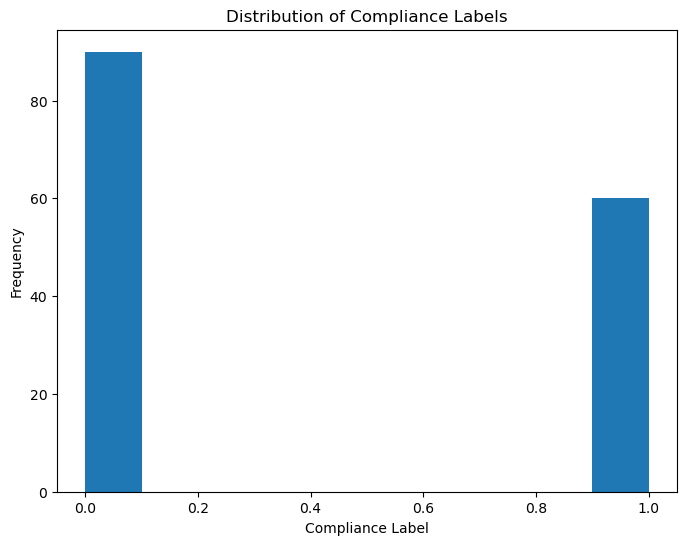

In [30]:
plt.figure(figsize=(8,6))
plt.hist(mydataset['compliance_label'],bins=10)
plt.xlabel('Compliance Label')
plt.ylabel('Frequency')
plt.title('Distribution of Compliance Labels')
plt.show()

<Axes: >

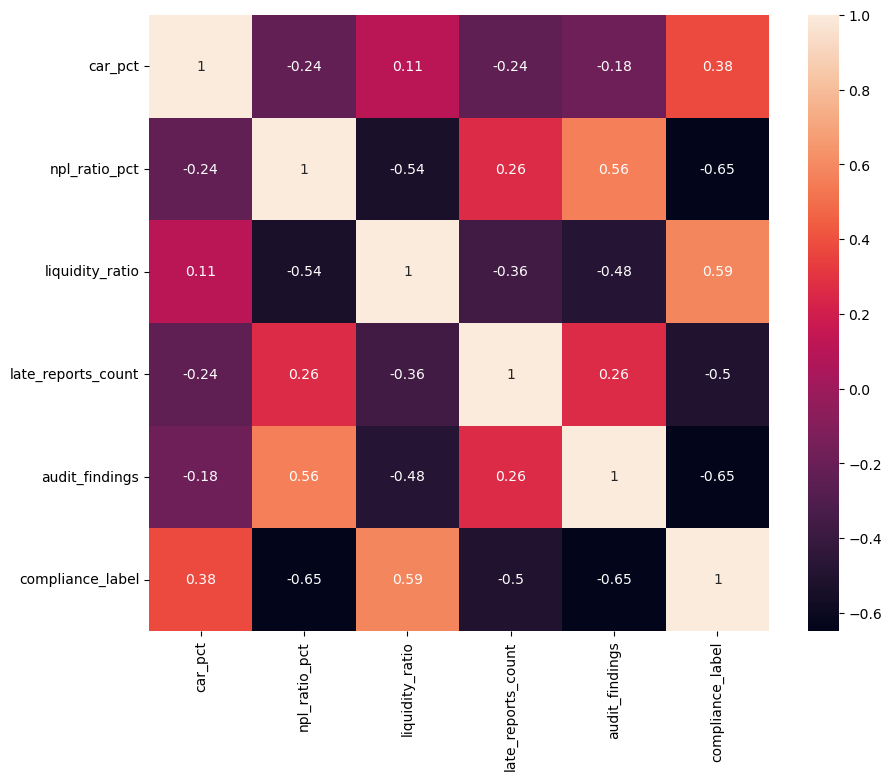

In [31]:
# 'institution_id' has been dropped and 'compliance_label' converted in an earlier cell.
# 'institution_type' is retained for later analysis, but excluded from correlation heatmap.
plt.figure(figsize=(10,8))
sns.heatmap(mydataset.select_dtypes(include=['number']).corr(), annot=True)

In [32]:
# Separate features and target
X_all = mydataset.drop('compliance_label', axis=1)
y = mydataset['compliance_label']

# Split data into training and test sets, keeping 'institution_type' in X_test_analysis
X_train_full, X_test_full, y_train, y_test = train_test_split(X_all, y, test_size=0.2, random_state=42)

# Create X_train and X_test for model training (without 'institution_type')
# 'institution_type' is categorical and should not be directly scaled or fed to models without encoding
X_train = X_train_full.drop('institution_type', axis=1)
X_test = X_test_full.drop('institution_type', axis=1)

# X_test_analysis contains 'institution_type' and other features for later per-group analysis
X_test_analysis = X_test_full

In [33]:
print(X_test_full)

           institution_type  car_pct  npl_ratio_pct  liquidity_ratio  \
73   MFI (Informal clients)      5.0           22.8             27.7   
18        SACCO (SME focus)     16.0           15.2             22.9   
118       SACCO (SME focus)      8.0            9.4             28.1   
78          Commercial Bank     17.7            6.3             41.6   
76   MFI (Informal clients)     15.6            5.9             19.4   
31          Commercial Bank     16.5            7.4             40.7   
64        SACCO (SME focus)     18.6           11.4             10.0   
141       SACCO (SME focus)      7.0           15.1             26.9   
68          Commercial Bank     22.2            4.7             26.1   
82          Commercial Bank     14.2            2.7             51.9   
110       SACCO (SME focus)     14.8            8.1             30.4   
12          Commercial Bank     19.2            6.3             31.0   
36        SACCO (SME focus)     16.0            7.9             

In [34]:
print(y.value_counts())

compliance_label
0    90
1    60
Name: count, dtype: int64


In [35]:
scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

In [36]:
model=LogisticRegression(class_weight='balanced')
model.fit(X_train_scaled,y_train)
y_pred=model.predict(X_test_scaled)
print(classification_report(y_test,y_pred))
print(confusion_matrix(y_test,y_pred))
print(accuracy_score(y_test,y_pred))

              precision    recall  f1-score   support

           0       1.00      0.85      0.92        20
           1       0.77      1.00      0.87        10

    accuracy                           0.90        30
   macro avg       0.88      0.93      0.89        30
weighted avg       0.92      0.90      0.90        30

[[17  3]
 [ 0 10]]
0.9


In [37]:
from sklearn.model_selection import GridSearchCV
param_grid={
    'max_depth':[3,4,5,6,7,8],
    'min_samples_split':[2,3,4],
    'min_samples_leaf':[1,2,3],
    'criterion':['gini','entropy']
}
grid = GridSearchCV(DecisionTreeClassifier(random_state=42),
                    param_grid, cv=5, scoring='f1_macro')
grid.fit(X_train, y_train)


best_dt = grid.best_estimator_

In [38]:
y_pred2=best_dt.predict(X_test)
print(classification_report(y_test,y_pred2))
print(confusion_matrix(y_test,y_pred2))
print(accuracy_score(y_test,y_pred2))
#

              precision    recall  f1-score   support

           0       1.00      0.90      0.95        20
           1       0.83      1.00      0.91        10

    accuracy                           0.93        30
   macro avg       0.92      0.95      0.93        30
weighted avg       0.94      0.93      0.93        30

[[18  2]
 [ 0 10]]
0.9333333333333333


In [43]:
#Decision tree without GridSearch
model2=DecisionTreeClassifier(max_depth=4,min_samples_leaf=10,random_state=42)
model2.fit(X_train,y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,4
,min_samples_split,2
,min_samples_leaf,10
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [44]:
analysis_df = X_test_analysis.copy()
analysis_df['actual'] = y_test
analysis_df['predicted'] = y_pred2

results = []
for inst in analysis_df['institution_type'].unique():
    subset = analysis_df[analysis_df['institution_type'] == inst]
    results.append({
        'Institution Type': inst,
        'Total': len(subset),
        'Accuracy': round((subset['actual'] == subset['predicted']).mean(), 2),
        'Precision': round(precision_score(subset['actual'], subset['predicted'], zero_division=0), 2),
        'Recall': round(recall_score(subset['actual'], subset['predicted'], zero_division=0), 2),
        'F1 Score': round(f1_score(subset['actual'], subset['predicted'], zero_division=0), 2)
    })

results_df = pd.DataFrame(results).sort_values('F1 Score', ascending=False)
print(results_df)

         Institution Type  Total  Accuracy  Precision  Recall  F1 Score
2         Commercial Bank     11      1.00        1.0     1.0       1.0
0  MFI (Informal clients)      8      0.75        0.0     0.0       0.0
1       SACCO (SME focus)     11      1.00        0.0     0.0       0.0


In [45]:
import joblib

In [46]:
FEATURE_ORDER=['car_pct','npl_ratio_pct','liquidity_ratio','late_reports_count','audit_findings']

In [47]:
joblib.dump(model2,'models/Fs04_Dtree_model.pkl')
joblib.dump(FEATURE_ORDER,'models/Fs04_feature_order.pkl')

['models/Fs04_feature_order.pkl']